# Bank Marketing Analytics & Customer Prediction

## Project Goal
The goal of this project is to predict whether a bank customer will subscribe to a term deposit based on customer and campaign-related features.

## Workflow
1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Model Building
7. Model Evaluation
8. Feature Importance
9. Conclusion


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)


In [59]:
import sys
from pathlib import Path

DIST = Path("../dist")
DIST.mkdir(parents=True, exist_ok=True)

log_file = open(DIST / "output.txt", "w", encoding="utf-8")
sys.stdout = log_file
sys.stderr = log_file


In [60]:
import re
import matplotlib.pyplot as plt

_original_show = plt.show
_plot_counter = 0

def _safe_name(text):
    text = str(text).strip()
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    return text.strip("_")[:80]

def _guess_name(fig, fallback_num):

    if getattr(fig, "_suptitle", None) is not None and fig._suptitle.get_text():
        return _safe_name(fig._suptitle.get_text())
    if fig.axes and fig.axes[0].get_title():
        return _safe_name(fig.axes[0].get_title())
    return f"plot_{fallback_num:03d}"

def show_and_save(*args, **kwargs):
    global _plot_counter
    
    fignums = plt.get_fignums()
    for num in fignums:
        fig = plt.figure(num)
        _plot_counter += 1
        fname = f"{_plot_counter:03d}_{_guess_name(fig, _plot_counter)}.png"
        
        fig.savefig(DIST / fname, dpi=300, bbox_inches="tight")
    
    _original_show(*args, **kwargs)

    plt.close("all")
plt.show = show_and_save


In [61]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


In [62]:
df = pd.read_csv("../data/bank-additional-full.csv", sep=";")
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [63]:
df_original = df.copy()


## 1. Data Understanding
In this section, we explore the dataset structure, data types, and summary statistics.
ب

In [64]:
df.shape


(41188, 21)

In [65]:
df.info()


In [66]:
df.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [67]:
df.isnull().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [68]:
df.duplicated().sum()


np.int64(12)

In [69]:
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])

print(df.shape)
print(df.columns.tolist())


## 2. Target Variable Analysis
We check the distribution of the target variable to understand class balance.


In [70]:
df['y'].value_counts()


y
no     36548
yes     4640
Name: count, dtype: int64

In [71]:
df['y'].value_counts(normalize=True) * 100


y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

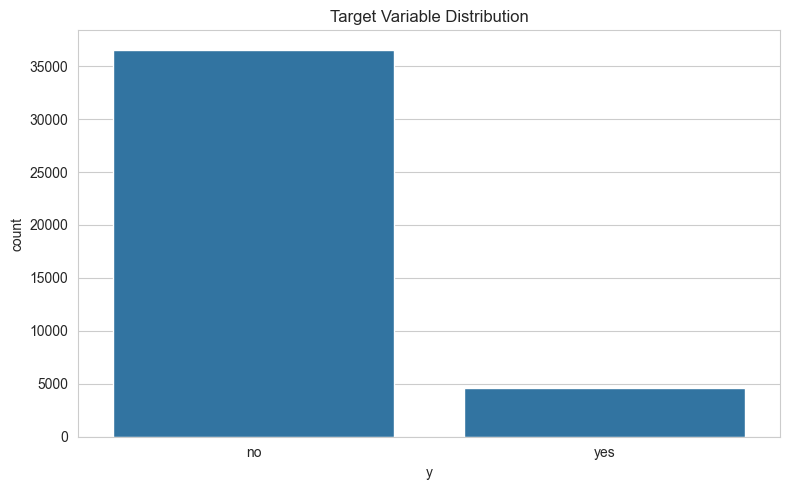

In [72]:
plt.figure(figsize=(8, 5))
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.tight_layout()
plt.show()
plt.close()


## 3. Exploratory Data Analysis (EDA)
We explore numerical and categorical features and their relationship with the target.


In [73]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_colsnumerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)



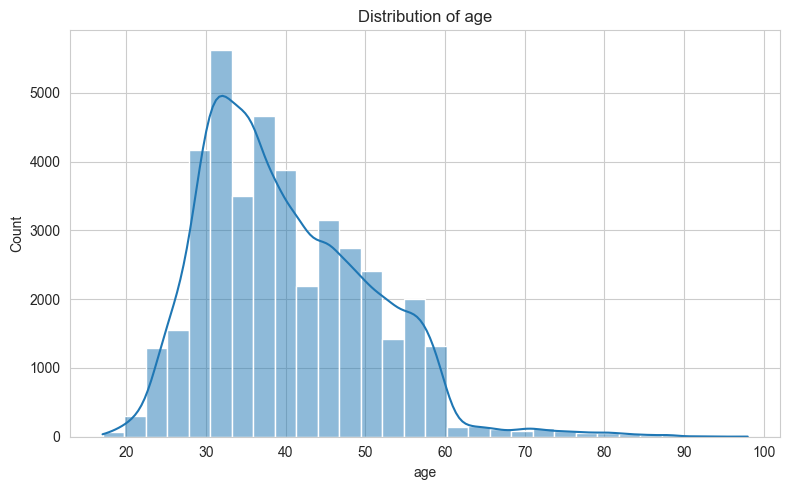

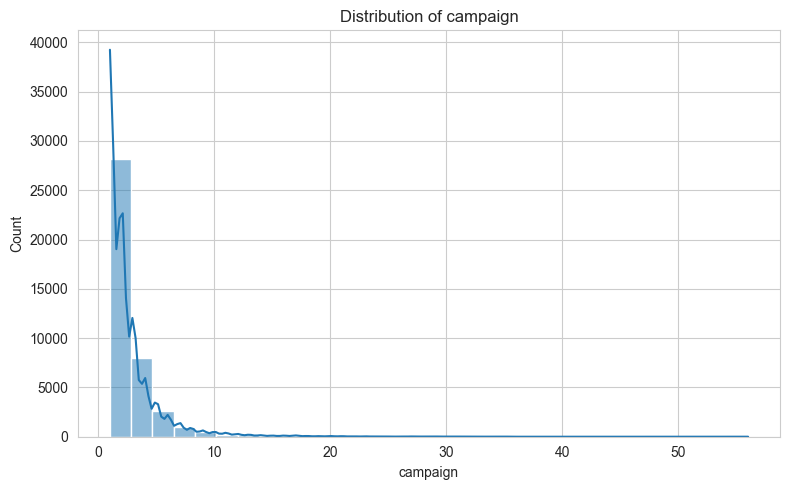

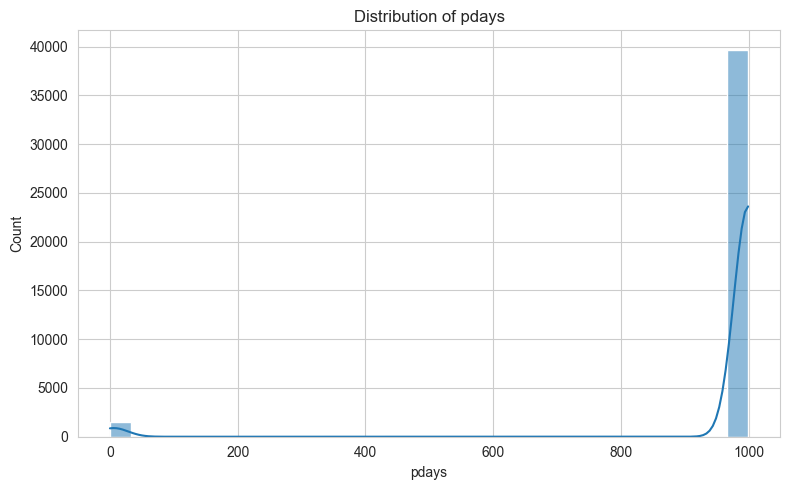

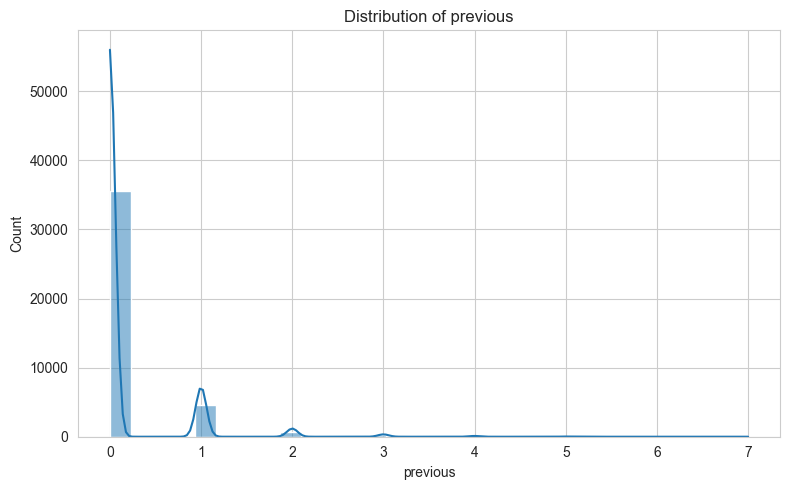

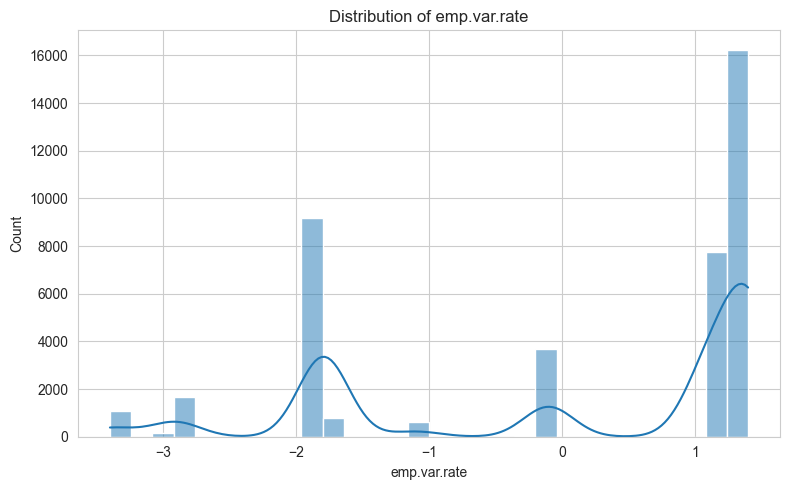

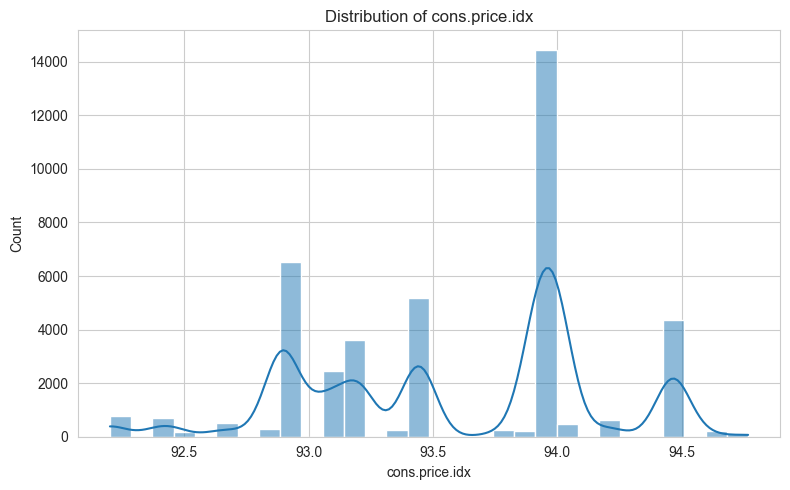

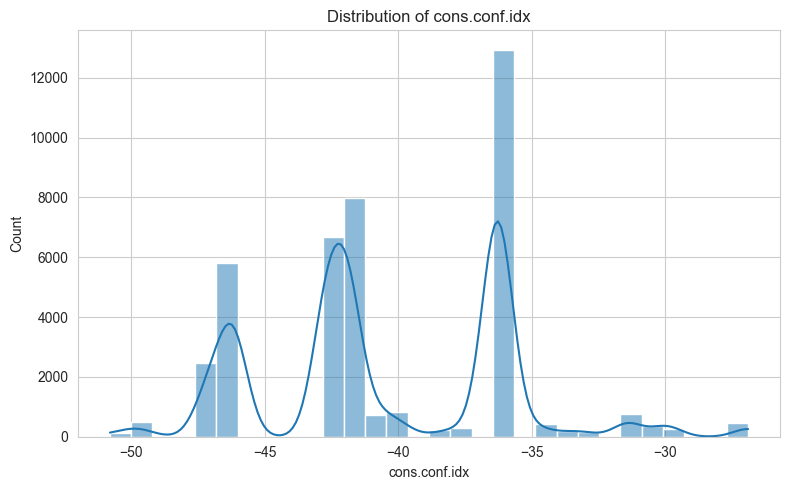

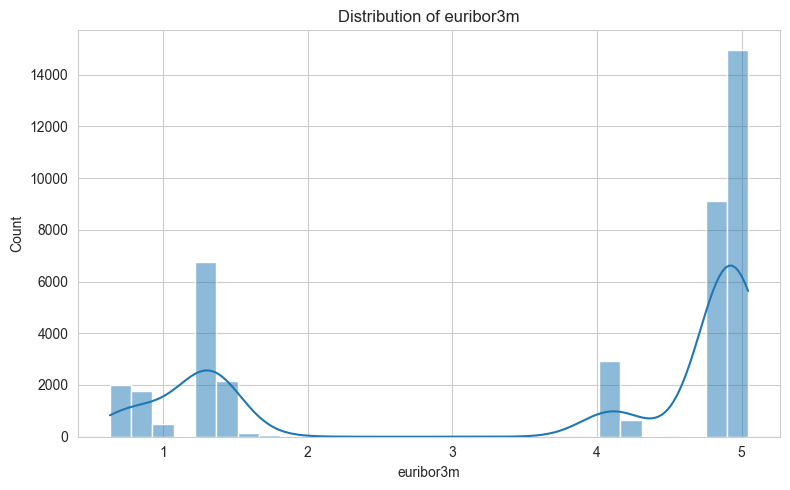

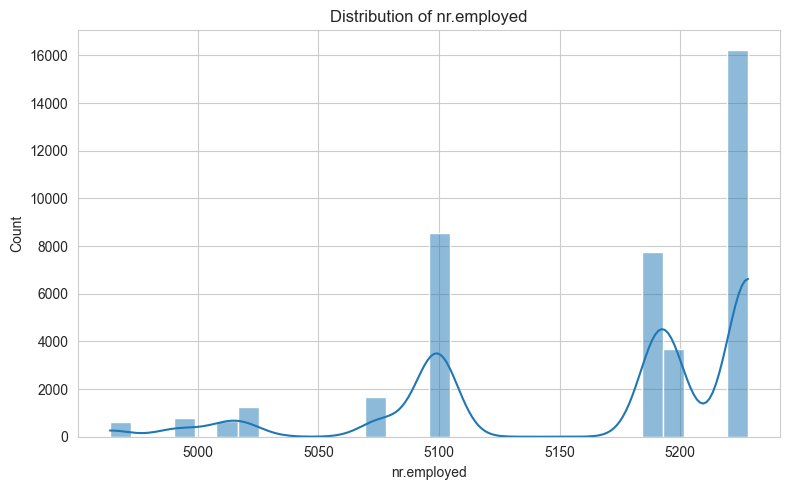

In [74]:
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()
    plt.close()


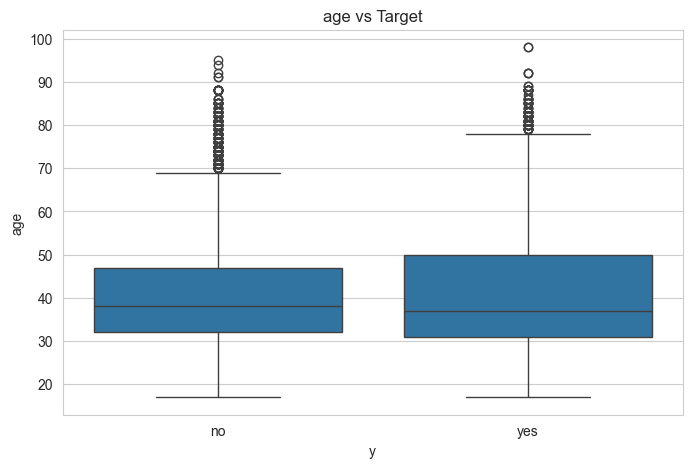

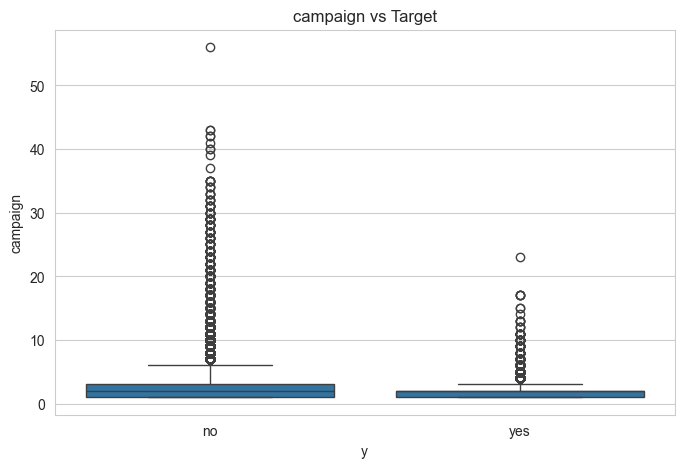

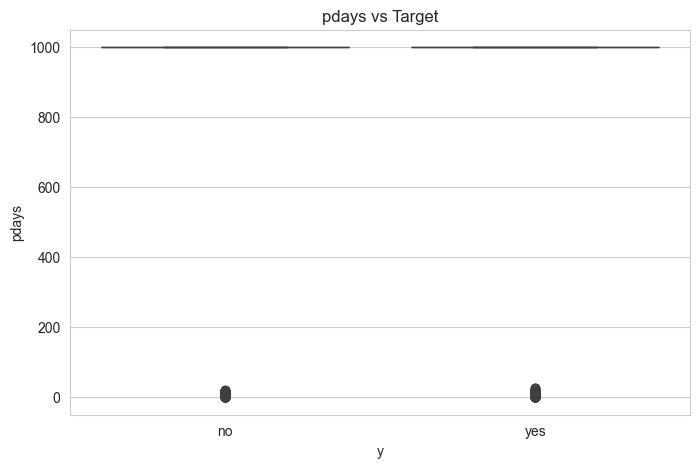

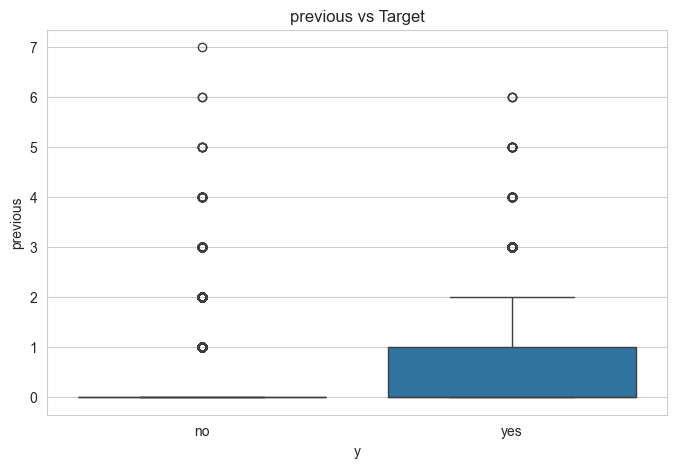

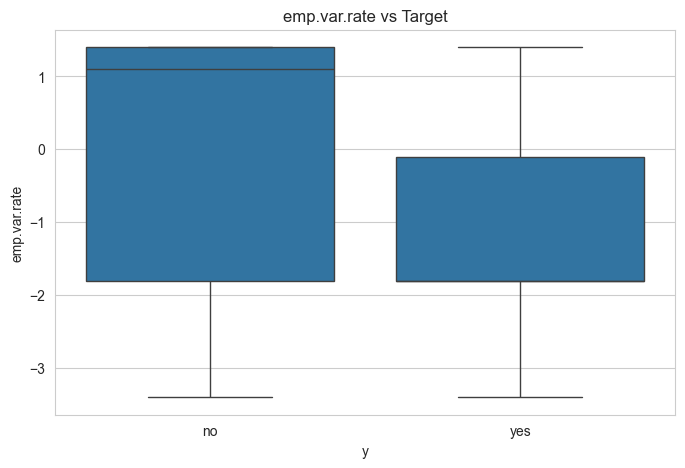

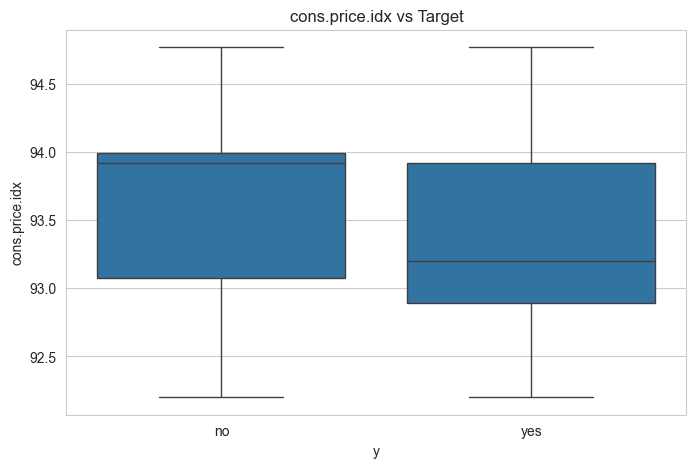

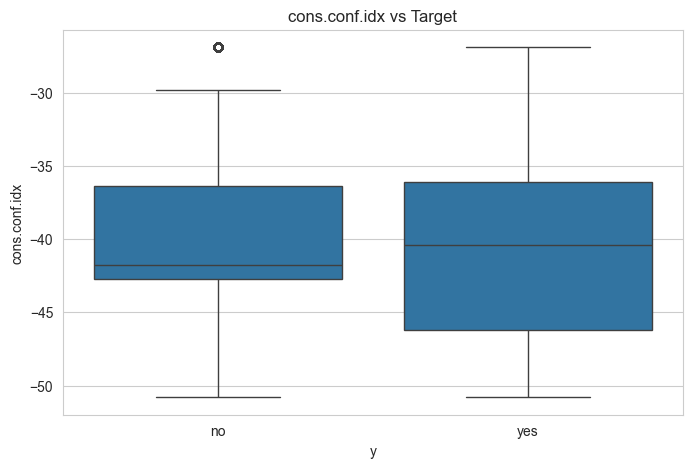

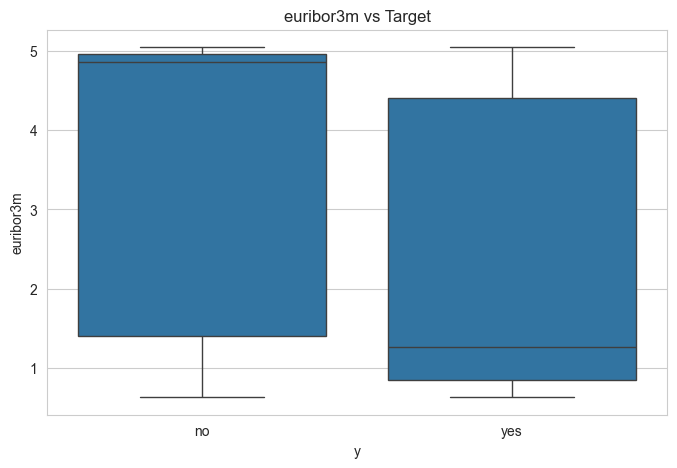

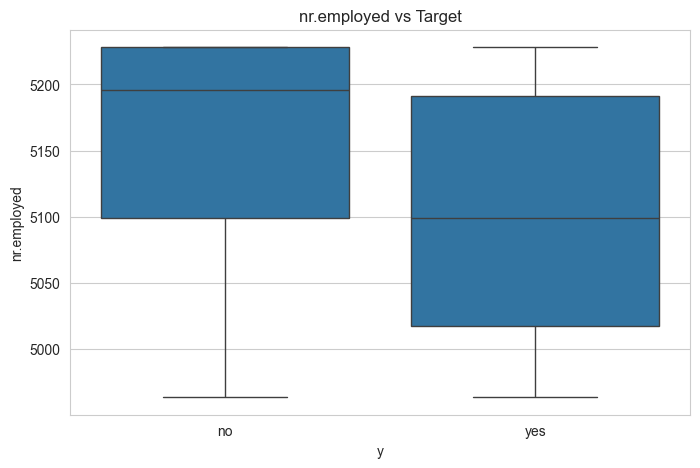

In [75]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()


In [76]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [77]:
categorical_cols.remove('y')
categorical_cols



['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

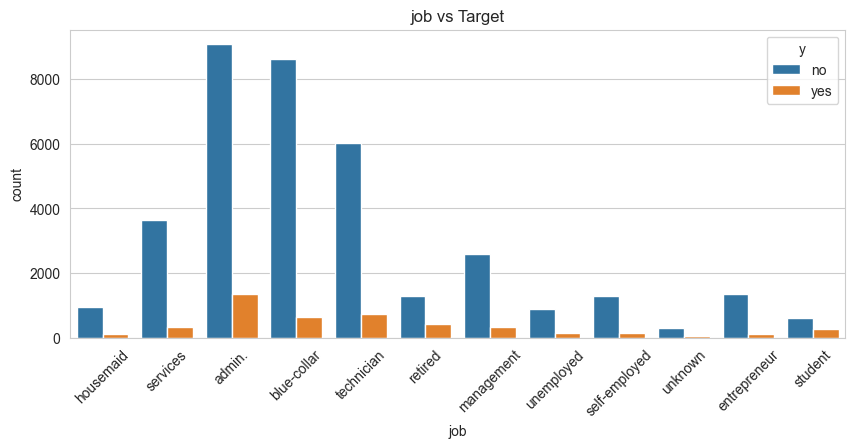

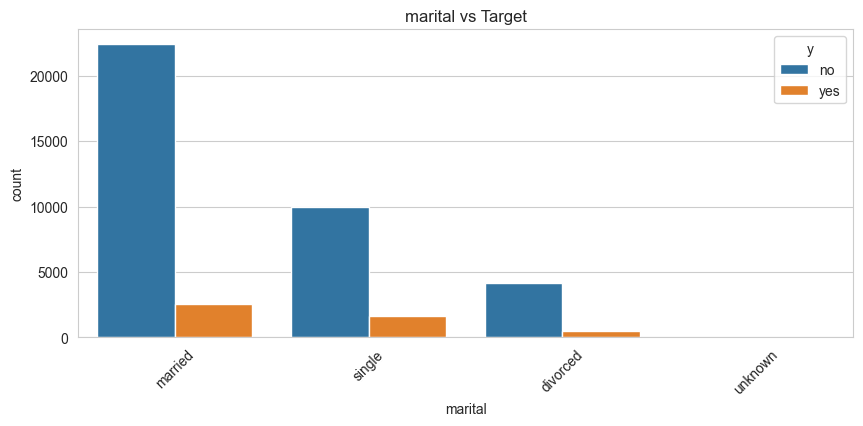

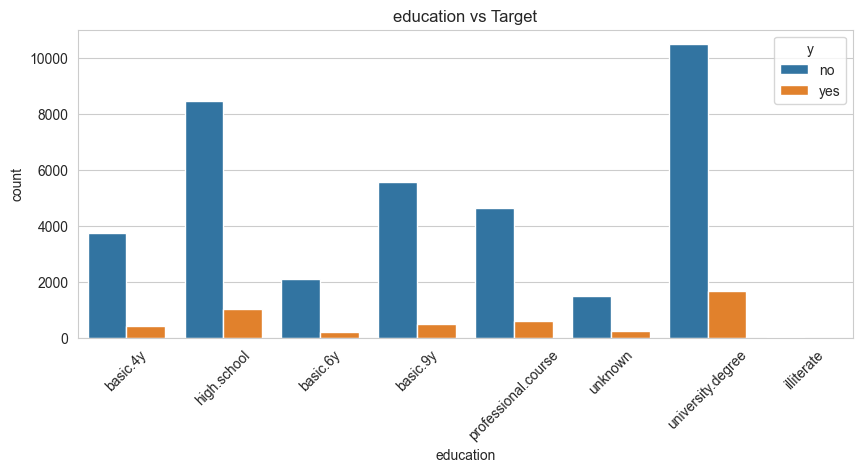

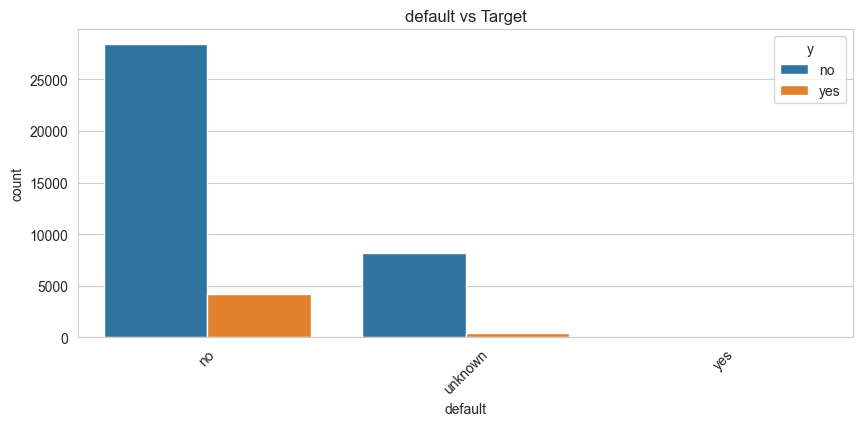

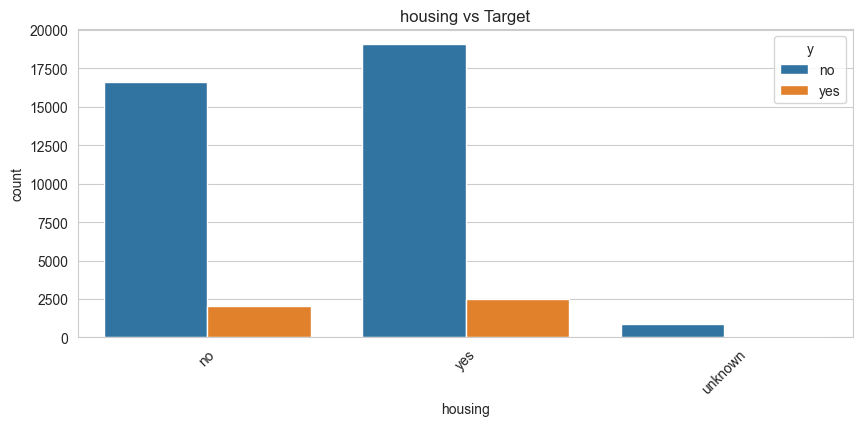

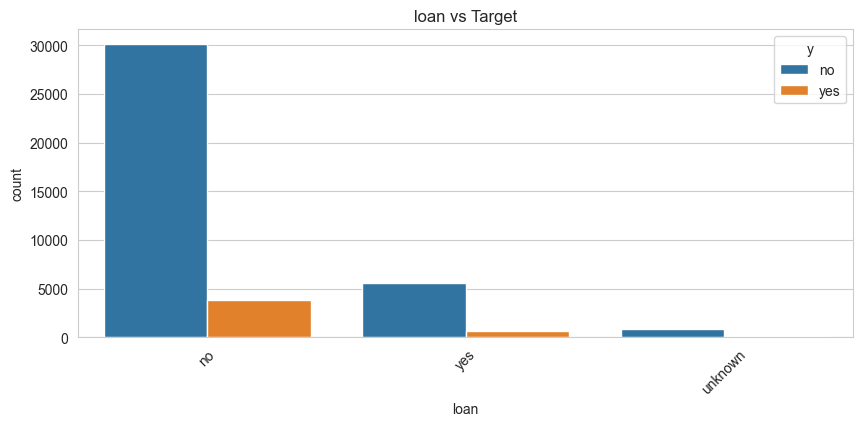

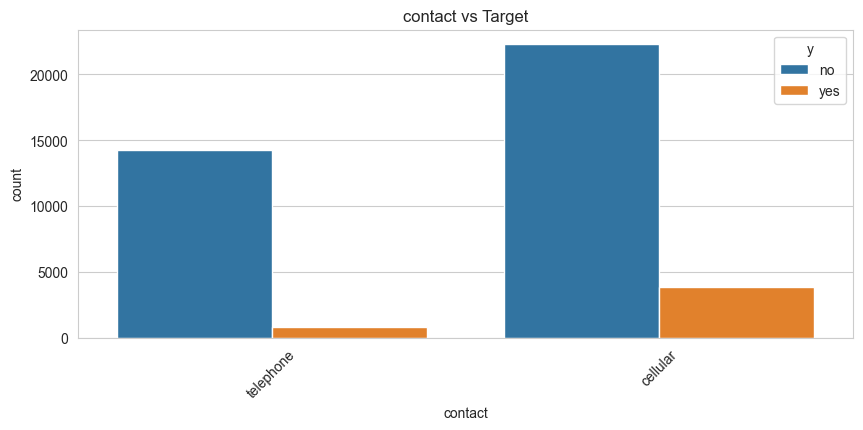

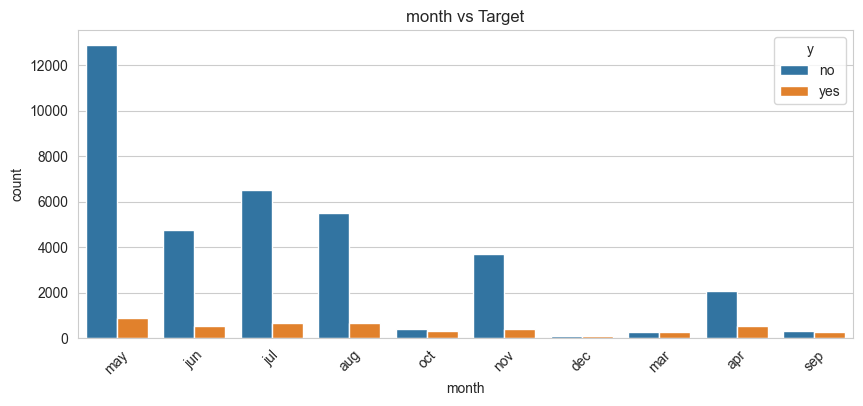

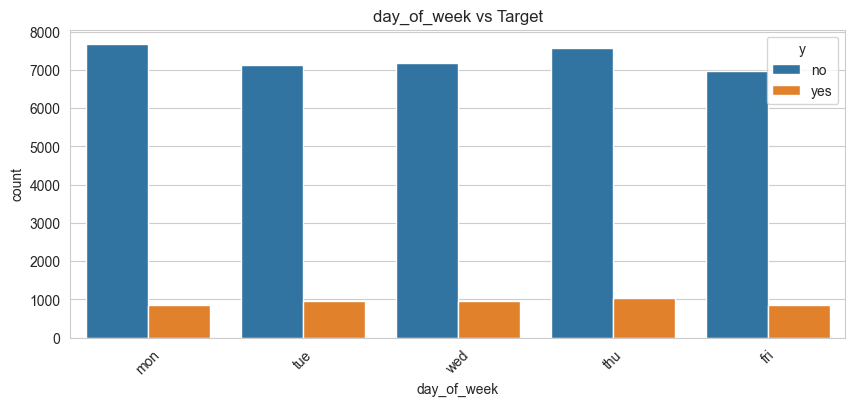

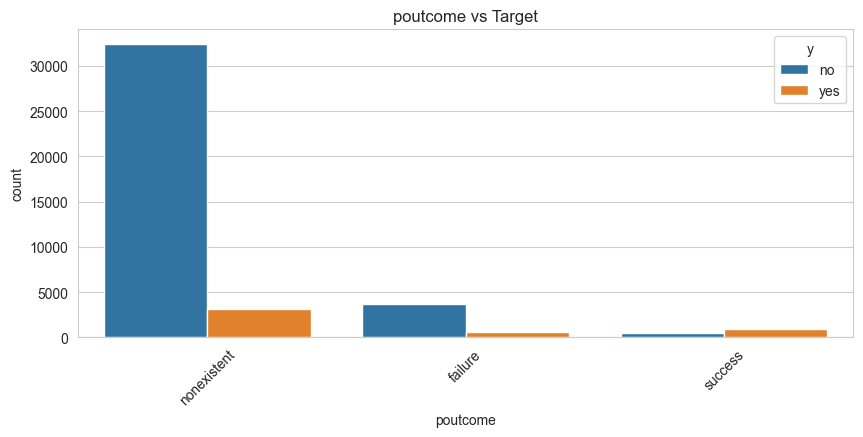

In [78]:
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, hue='y', data=df)
    plt.title(f"{col} vs Target")
    plt.xticks(rotation=45)
    plt.show()


## 4. Data Cleaning and Encoding
Machine learning models require numeric input, so we convert the target and categorical variables.
ر

In [79]:
# Remove duration to avoid data leakage
if 'duration' in df.columns:
    df = df.drop('duration', axis=1)

df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [80]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
df['y'].head()


0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [81]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False


In [82]:
df_encoded.shape


(41188, 53)

In [83]:
df_encoded.info()


In [84]:
corr_with_target = df_encoded.corr()['y'].sort_values(ascending=False)
corr_with_target.head(15)


y                              1.000000
poutcome_success               0.316269
previous                       0.230181
month_mar                      0.144014
month_oct                      0.137366
month_sep                      0.126067
job_student                    0.093955
job_retired                    0.092221
month_dec                      0.079303
cons.conf.idx                  0.054878
marital_single                 0.054133
education_university.degree    0.050364
age                            0.030399
education_unknown              0.021430
job_unemployed                 0.014752
Name: y, dtype: float64

In [85]:
corr_with_target.tail(15)


month_jul              -0.032230
job_services           -0.032301
marital_married        -0.043398
education_basic.9y     -0.045135
campaign               -0.066357
job_blue-collar        -0.074423
default_unknown        -0.099293
month_may              -0.108271
cons.price.idx         -0.136211
contact_telephone      -0.144773
poutcome_nonexistent   -0.193507
emp.var.rate           -0.298334
euribor3m              -0.307771
pdays                  -0.324914
nr.employed            -0.354678
Name: y, dtype: float64

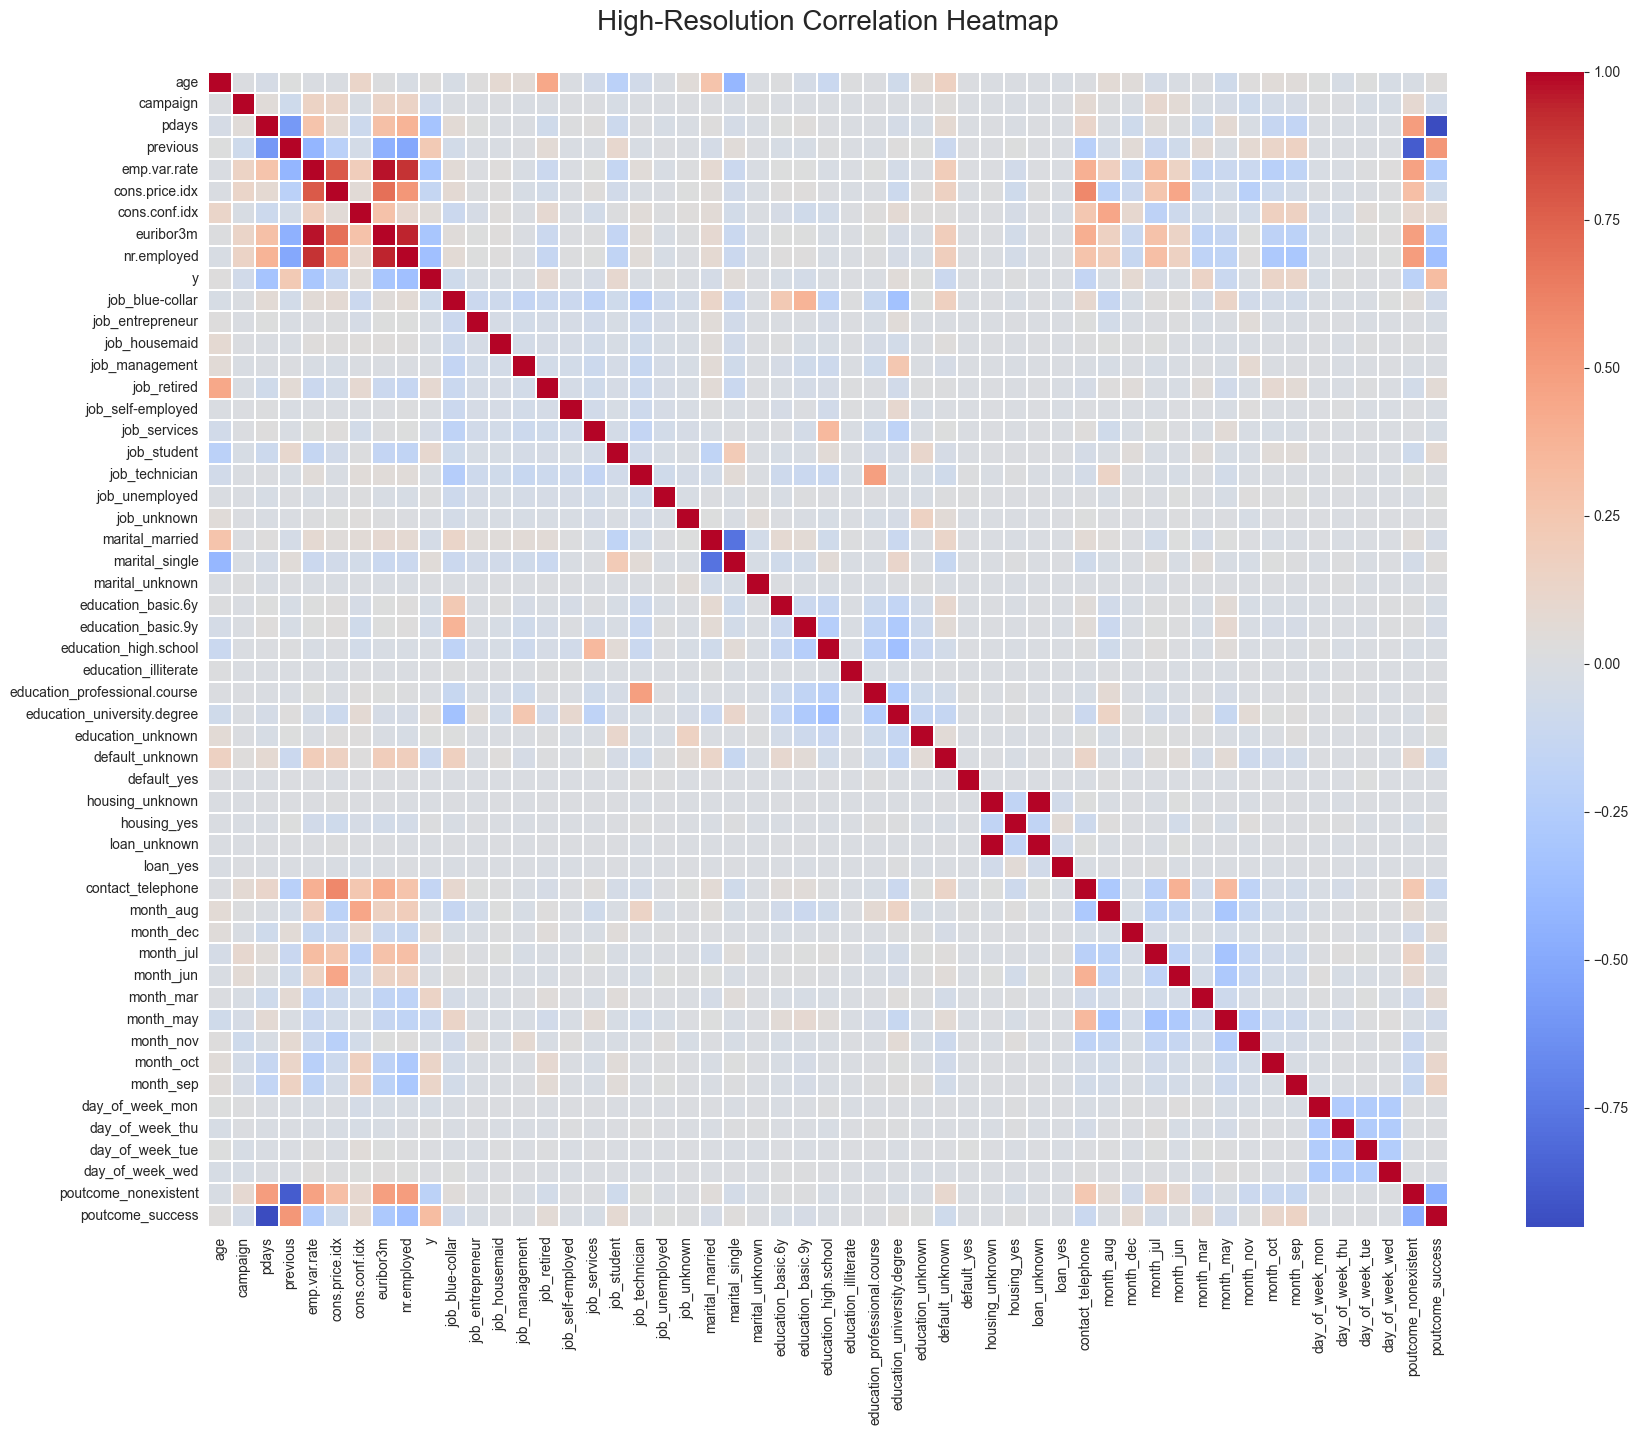

In [86]:

plt.figure(figsize=(20, 15), dpi=100)

sns.heatmap(df_encoded.corr(), 
            cmap='coolwarm', 
            annot=False,  
            fmt=".2f", 
            linewidths=0.1, 
            linecolor='white')

plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)

plt.title('High-Resolution Correlation Heatmap', fontsize=20, pad=30)
plt.show()


In [87]:
df_model = df_encoded.copy()


In [88]:
X = df_model.drop('y', axis=1)
y = df_model['y']


In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [90]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


## 5. Feature Scaling
Scaling is important for models like Logistic Regression.


In [91]:
scaler = StandardScaler()


In [92]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Model 1: Logistic Regression
Logistic Regression is a simple and interpretable baseline classification model.


In [93]:
lr = LogisticRegression(max_iter=2000, class_weight='balanced')


In [94]:
lr.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [95]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]


In [96]:
print("Logistic Regression - Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))


In [97]:
print("Logistic Regression - Classification Report")
print(classification_report(y_test, y_pred_lr))


In [98]:
lr_auc = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression ROC-AUC:", lr_auc)


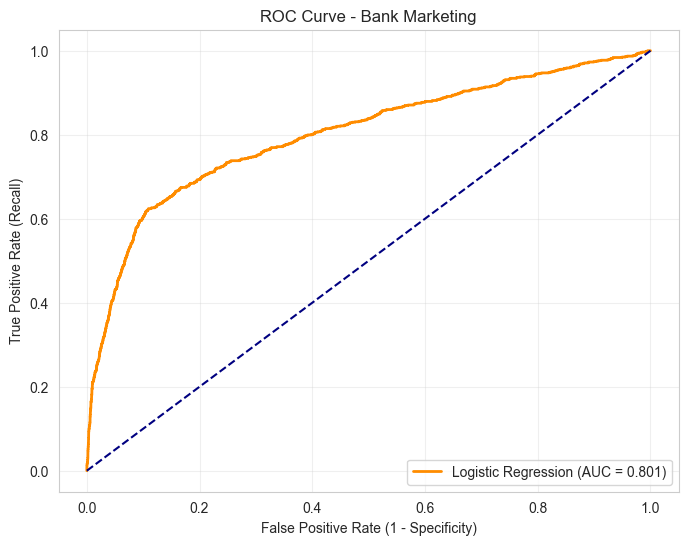

In [99]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Bank Marketing')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


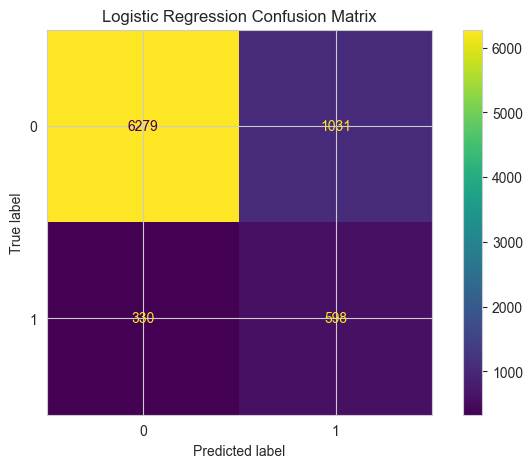

In [100]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## 7. Model 2: Random Forest
Random Forest is an ensemble model that combines multiple decision trees.


In [101]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)


In [102]:
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [103]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]


In [104]:
print("Random Forest - Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))


In [105]:
print("Random Forest - Classification Report")
print(classification_report(y_test, y_pred_rf))


In [106]:
rf_auc = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC:", rf_auc)


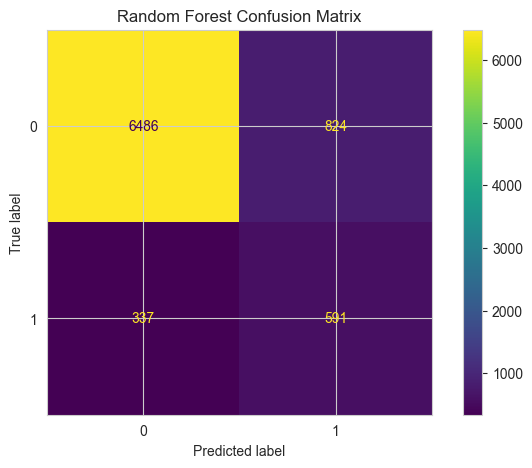

In [107]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()


## 8. Model Comparison
We compare model performance using ROC-AUC.


In [108]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC_AUC': [lr_auc, rf_auc]
})

comparison_df


,Model,ROC_AUC
0,Logistic Regression,0.800878
1,Random Forest,0.813438


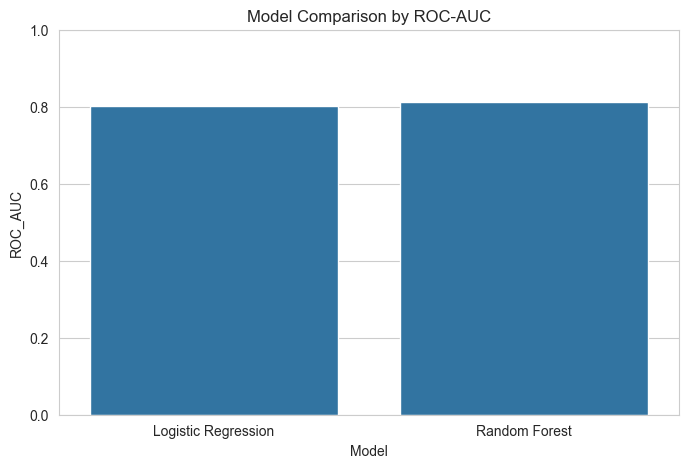

In [109]:
sns.barplot(data=comparison_df, x='Model', y='ROC_AUC')
plt.title("Model Comparison by ROC-AUC")
plt.ylim(0, 1)
plt.show()


## 9. Feature Importance
This helps identify which features contributed most to the model predictions.


In [110]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
top_10_features = feature_importance.sort_values(ascending=False).head(10)
top_10_features


euribor3m            0.190303
nr.employed          0.156148
emp.var.rate         0.138134
cons.conf.idx        0.078933
pdays                0.054668
cons.price.idx       0.052733
poutcome_success     0.038074
age                  0.035699
contact_telephone    0.028252
month_may            0.027531
dtype: float64

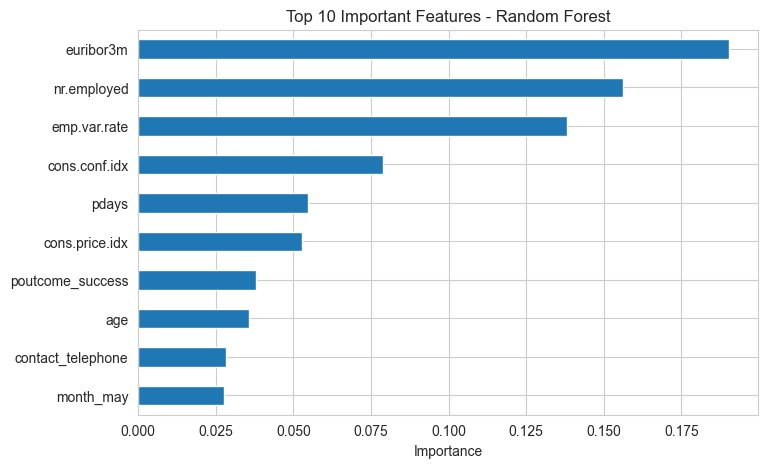

In [111]:
top_10_features.sort_values().plot(kind='barh')
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.show()


## 11. Conclusion

### Summary
- The dataset was explored and cleaned.
- Categorical variables were encoded into numerical format.
- Logistic Regression and Random Forest models were trained and evaluated.
- Random Forest generally provided better predictive performance.
- Feature importance analysis showed which variables were most influential.
- A business-realistic version without `duration` was also tested to reduce data leakage risk.

### Business Impact
This project can help banks identify high-potential customers and improve marketing efficiency by targeting the right audience.
